In [1]:
import os

if not os.path.exists('thinkdsp.py'):
    !wget https://github.com/AllenDowney/ThinkDSP/raw/master/code/thinkdsp.py
    !wget https://github.com/AllenDowney/ThinkDSP/raw/master/code/thinkplot.py

import thinkdsp
import thinkplot

--2026-05-19 21:08:30--  https://github.com/AllenDowney/ThinkDSP/raw/master/code/thinkdsp.py
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/AllenDowney/ThinkDSP/master/code/thinkdsp.py [following]
--2026-05-19 21:08:30--  https://raw.githubusercontent.com/AllenDowney/ThinkDSP/master/code/thinkdsp.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 48554 (47K) [text/plain]
Saving to: ‘thinkdsp.py’

thinkdsp.py         100%[===================>]  47.42K  --.-KB/s    in 0.03s   

2026-05-19 21:08:31 (1.34 MB/s) - ‘thinkdsp.py’ saved [48554/48554]

--2026-05-19 21:08:31--  https://github.com/Allen

# 8.1

При увеличении std окно становится шире во временноой области, следовательно, полоса пропускания фильтра сужается (частота среза уменьшается). При малых std окно узкое, и фильтр пропускает много высоких частот, сглаживание слабое. Если менять std, но сохранять M, то при очень малых std (например, 1) окно будет иметь резкие края, что приведёт к появлению боковых лепестков (как у прямоугольного окна)

# 8.2

Измеренная ширина спектра (sigma_f) = 5.63 Гц
Теоретическая (1/(2πσ_t * dt)) = 7.96 Гц


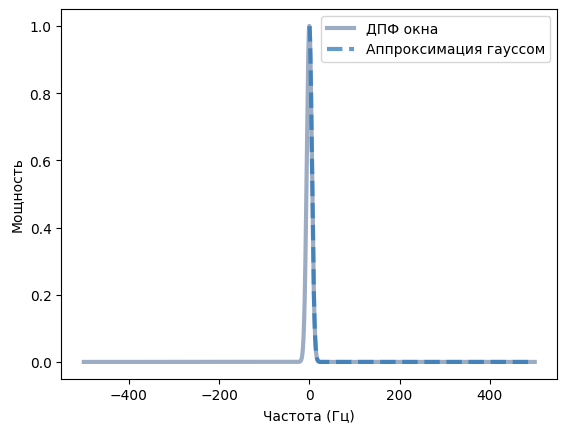

<Figure size 800x600 with 0 Axes>

In [6]:
import numpy as np
import scipy

def gaussian(x, a, mu, sigma):
    return a * np.exp(-(x - mu)**2 / (2 * sigma**2))

# Параметры
M = 201          # длина окна
std_t = 20       # стандартное отклонение во временной области (отсчёты)
framerate = 1000 # условная частота дискретизации


window = scipy.signal.windows.gaussian(M, std=std_t)
window = window / window.sum()


N = 4096
padded = np.zeros(N)
padded[:M] = window
fft_window = np.fft.fftshift(np.fft.fft(padded))
freqs = np.fft.fftshift(np.fft.fftfreq(N, d=1/framerate))
power = np.abs(fft_window)**2

mask = freqs > 0
freqs_pos = freqs[mask]
power_pos = power[mask]

popt, _ = scipy.optimize.curve_fit(gaussian, freqs_pos, power_pos,
                             p0=[power_pos.max(), 0, 10])
a, mu, sigma_f = popt
print(f"Измеренная ширина спектра (sigma_f) = {sigma_f:.2f} Гц")
print(f"Теоретическая (1/(2πσ_t * dt)) = {1/(2*np.pi*std_t*(1/framerate)):.2f} Гц")

# Визуализация
thinkplot.plot(freqs, power, label='ДПФ окна', alpha = 0.4)
thinkplot.plot(freqs_pos, gaussian(freqs_pos, *popt), '--', label='Аппроксимация гауссом')
thinkplot.config(xlabel='Частота (Гц)', ylabel='Мощность')
thinkplot.show()

Так как гауссиана симметрична, аппроксимировалась только его половина

# 8.3

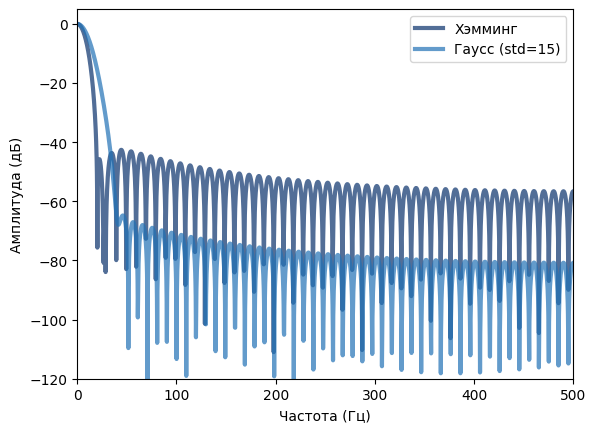

<Figure size 800x600 with 0 Axes>

In [9]:
import numpy as np
from scipy import signal

M = 101          # длина окна
framerate = 1000

# Окна
hamming_win = np.hamming(M)
gaussian_win = signal.windows.gaussian(M, std=15)

hamming_win = hamming_win / hamming_win.sum()
gaussian_win = gaussian_win / gaussian_win.sum()

# ДПФ
N = 4096
def compute_response(win):
    padded = np.zeros(N)
    padded[:M] = win
    fft_win = np.fft.rfft(padded)
    freqs = np.fft.rfftfreq(N, d=1/framerate)
    return freqs, 20*np.log10(np.abs(fft_win) + 1e-10)  # дБ

freqs, hamming_db = compute_response(hamming_win)
_, gaussian_db = compute_response(gaussian_win)

thinkplot.plot(freqs, hamming_db, label='Хэмминг')
thinkplot.plot(freqs, gaussian_db, label='Гаусс (std=15)')
thinkplot.config(xlabel='Частота (Гц)', ylabel='Амплитуда (дБ)', xlim=[0, framerate/2], ylim=[-120, 5])
thinkplot.show()

Для фильтрации НЧ, где требуется сильное подавление высоких частот, гауссово окно предпочтительнее. Однако оно шире во временной области (больше «размытие»).